# Merge scRNA-seq and snRNA-seq

In [1]:
set.seed(1)
source('./utils.R')

# Standard pipeline

## Load datasets

**Load sample info for treated lesions (FFPE)**

In [2]:
obj_sc = readRDS('../_data/ffpe/obj_27448cells_labeled_v2.rds')

**Load sample info for untreated lesions (OCT)**

In [3]:
obj_sn = readRDS('../_data/snRNAseq/obj_43854cells_labeled_v2.rds') 

**Merge on shared genes**

In [4]:
genes1 = rownames(obj_sc)
genes2 = rownames(obj_sn)
common_genes = intersect(genes1, genes2)
message("Number of genes in object 1: ", length(genes1))
message("Number of genes in object 2: ", length(genes2))
message("Number of common genes: ", length(common_genes))

# Select top 2000 variable genes per dataset
obj_sc = subset(obj_sc, features = common_genes) %>% 
        FindVariableFeatures(selection.method = "vst", nfeatures = 2000)
obj_sn = subset(obj_sn, features = common_genes) %>% 
        FindVariableFeatures(selection.method = "vst", nfeatures = 2000)

obj_merged = merge(obj_sc, obj_sn, add.cell.ids = c("sc", "sn"), project = "merged")
obj_merged

# Select the union of variable genes in each dataset
vargenes_sc = VariableFeatures(obj_sc)
vargenes_sn = VariableFeatures(obj_sn)
vargenes = intersect(common_genes, union(vargenes_sc, vargenes_sn))

message("Number of vargenes in object 1: ", length(vargenes_sc))
message("Number of vargenes in object 2: ", length(vargenes_sn))
message("Number of common genes: ", length(vargenes))

# Exclude cell cycle and MT and ribosome genes
mt_ri = grep("^MT-|^RPL|^RPS|MALAT1|MIR-", rownames(obj_merged), value = TRUE)
cycle_prolif = c(Seurat::cc.genes$s.genes, Seurat::cc.genes$g2m.genes)
genes_exclude = union(mt_ri, cycle_prolif)
vargenes = vargenes[-which(vargenes %in% genes_exclude)]
message("Number of variable genes after exclusions: ", length(vargenes))

Number of genes in object 1: 16870

Number of genes in object 2: 31161

Number of common genes: 16399

Finding variable features for layer counts

Finding variable features for layer counts



An object of class Seurat 
16399 features across 71302 samples within 1 assay 
Active assay: RNA (16399 features, 2000 variable features)
 6 layers present: counts.ffpe, counts.nuc-seq, data.ffpe, scale.data.ffpe, data.nuc-seq, scale.data.nuc-seq

Number of vargenes in object 1: 2000

Number of vargenes in object 2: 2000

Number of common genes: 3148

Number of variable genes after exclusions: 3097



## Normalization and PCA

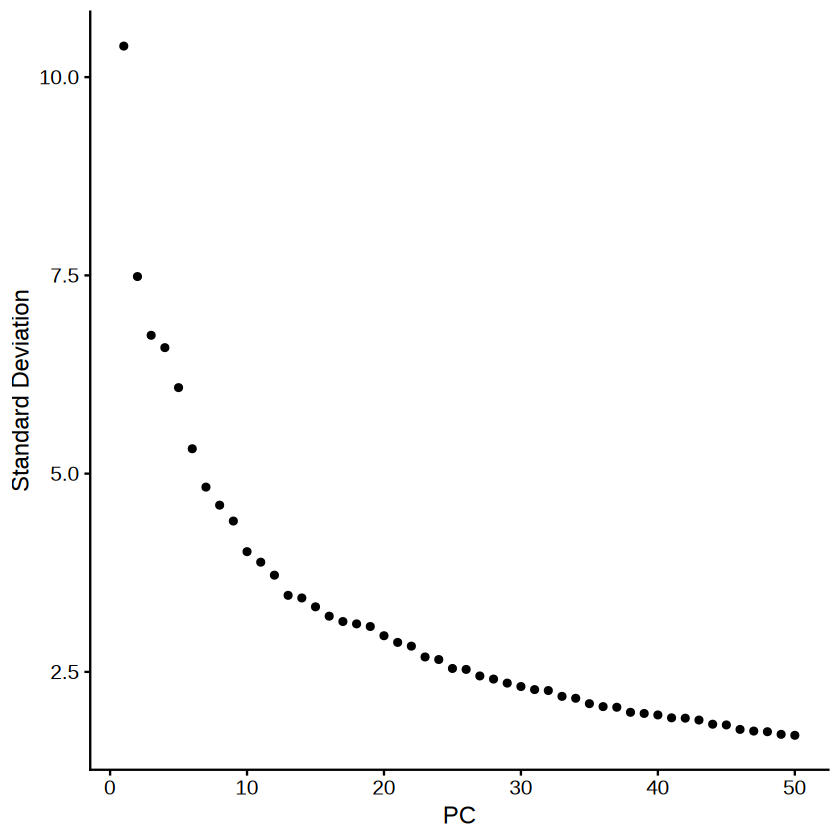

In [5]:
.verbose = FALSE
# Data already per-cell normalized
obj = obj_merged %>% ScaleData(features = rownames(obj_merged), verbose = .verbose) %>%
                RunPCA(features = vargenes, verbose = .verbose)
obj@meta.data$dataset = ifelse(obj@meta.data$dataset == 'ffpe', 'scRNA-seq', 'snRNA-seq')
ElbowPlot(obj, ndims = 50, reduction = "pca") # Elbow plot

Pre-harmony PCA

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



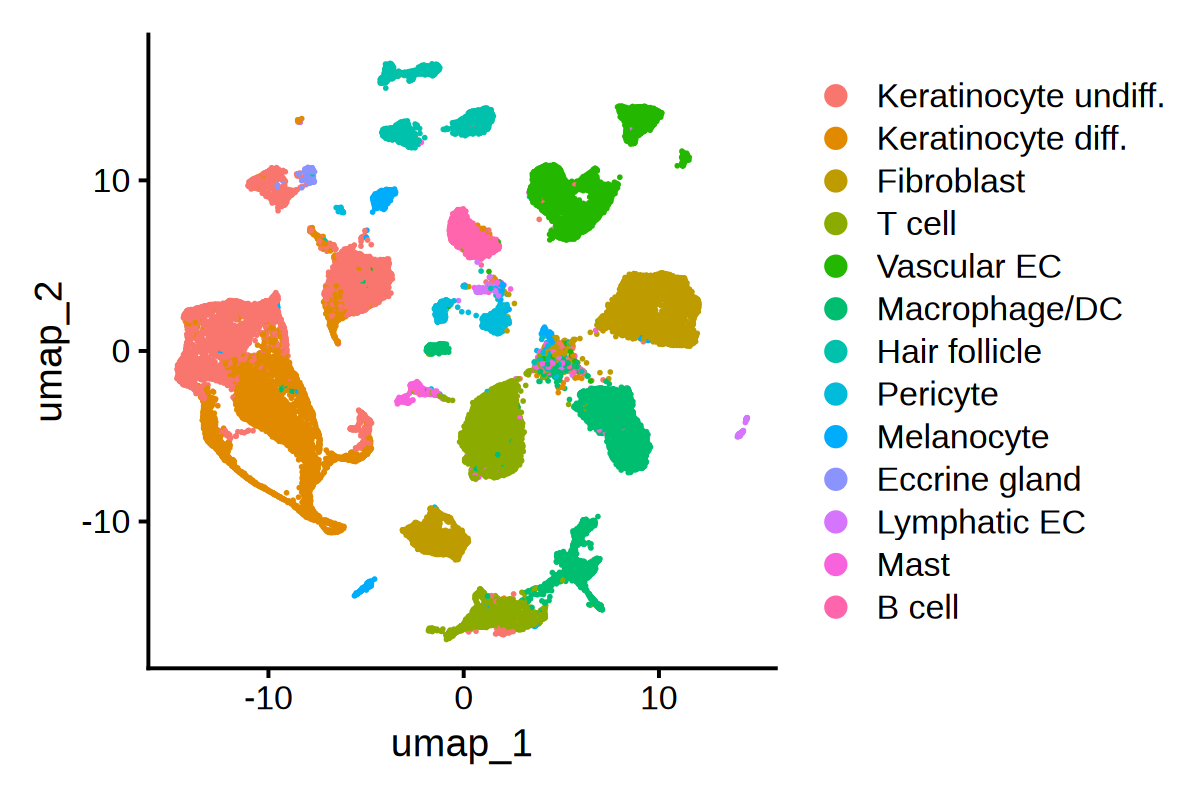

In [6]:
obj = obj %>% RunUMAP(dims = 1:30, verbose = .verbose)

fig.size(4, 6)
DimPlot(obj, reduction = "umap", shuffle = TRUE)

## Harmony

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony converged after 6 iterations

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



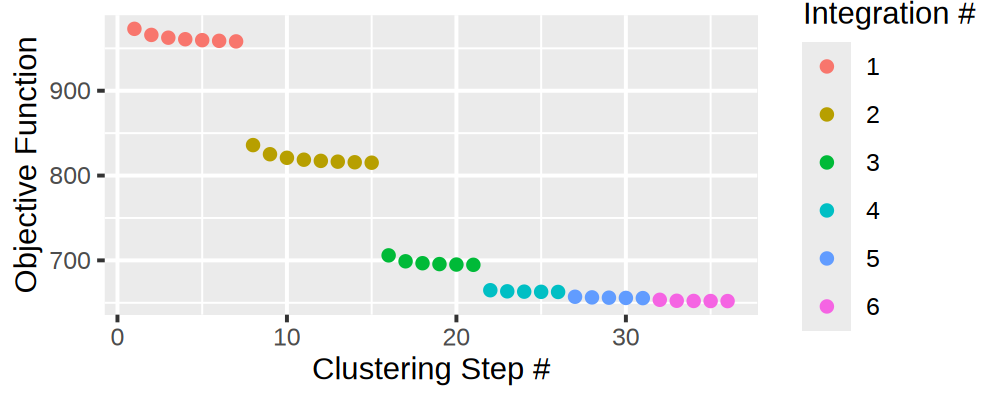

In [7]:
fig.size(2, 5)
set.seed(1)
obj = obj %>% RunHarmony(c("Subject", "dataset", "Run"), theta = c(1, 1, 1), plot_convergence = TRUE) %>%
    RunUMAP(reduction = "harmony", dims = 1:30, verbose = .verbose) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:30, verbose = .verbose) %>% 
    FindClusters(resolution = 0.2, verbose = .verbose) %>% 
    identity()

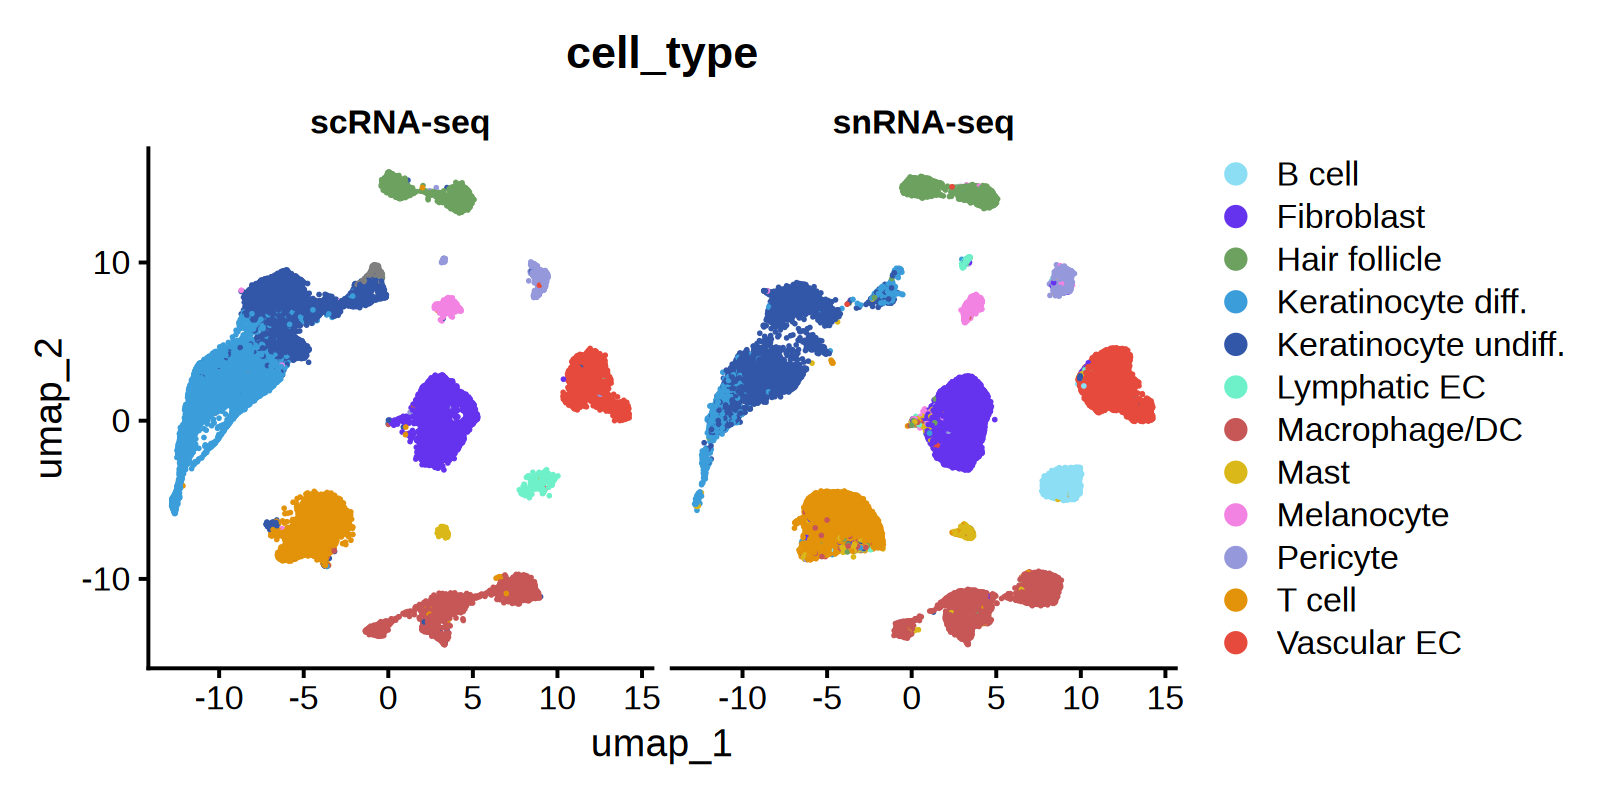

In [8]:
fig.size(4, 8)
DimPlot(obj, reduction = "umap", shuffle = TRUE, group.by = 'cell_type', split.by = 'dataset') + 
    scale_color_manual(values = custom.colors.nuc)

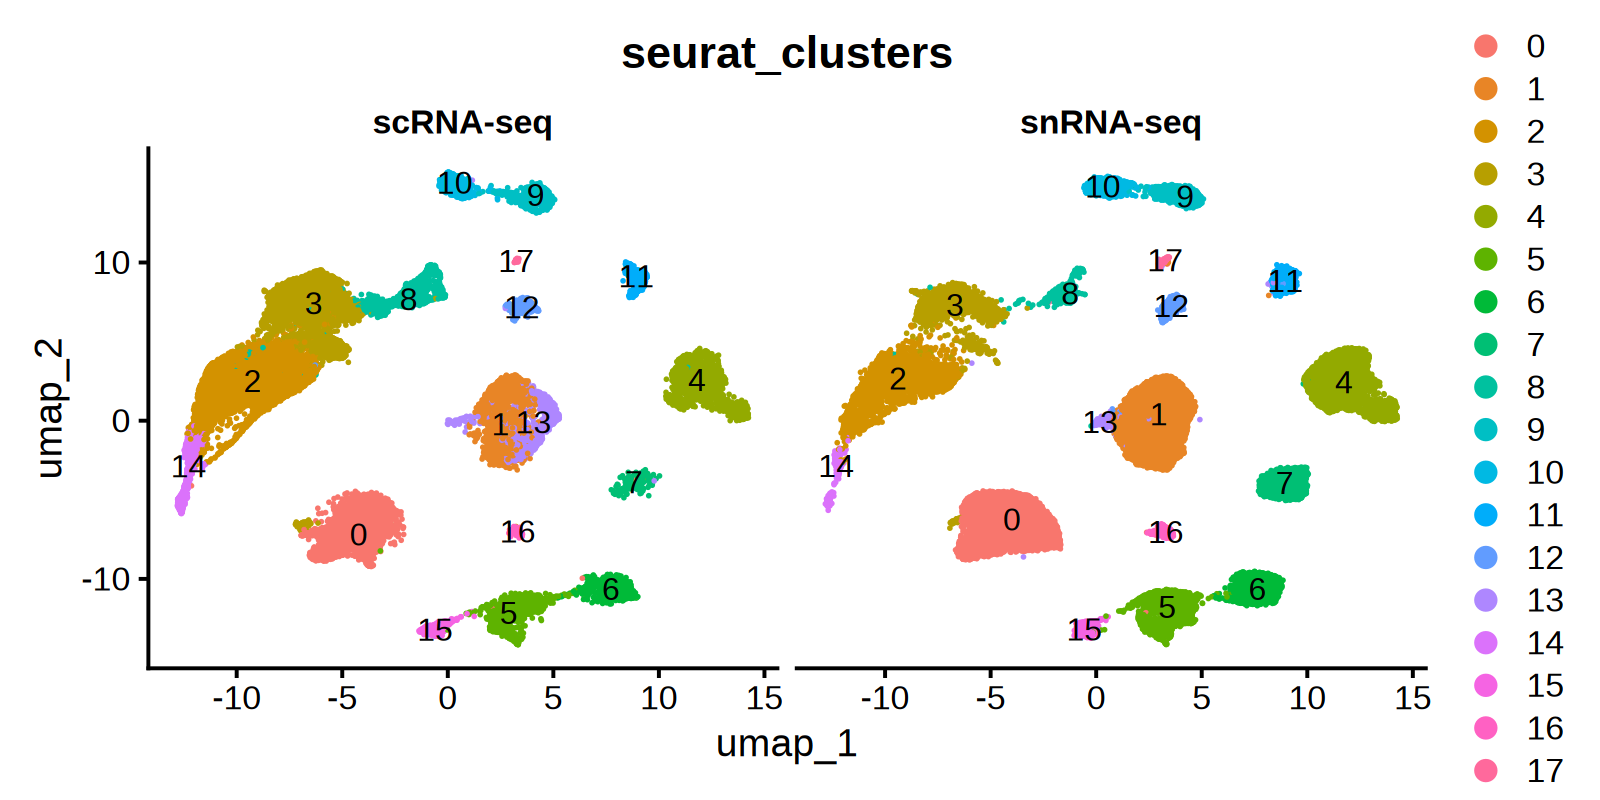

In [9]:
fig.size(4, 8)
DimPlot(obj, reduction = "umap", shuffle = TRUE, group.by = 'seurat_clusters', split.by = 'dataset', label = TRUE)

## Differential expression by cluster

In [10]:
obj_new = JoinLayers(obj)
data.input = GetAssayData(obj_new, assay = "RNA", layer = "data")
obj = obj_new
remove(obj_new)

,feature,group,avgExpr,logFC,statistic,auc,pval,padj,pct_in,pct_out
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SAMD11,0,0.0005339452,-0.001782920,380873628,0.4994530,7.263617e-04,9.092828e-04,0.02289552,0.1323047
2,NOC2L,0,0.0798856617,-0.060729072,357822102,0.4692247,8.326206e-112,4.210344e-111,3.55643746,9.9469063
3,KLHL17,0,0.0455335407,0.013007995,380432870,0.4988750,1.205434e-01,1.330635e-01,2.09112417,2.3454011
4,PLEKHN1,0,0.0316120474,-0.079495784,357363951,0.4686239,6.344569e-150,4.202124e-149,1.44241777,7.7870754
5,PERM1,0,0.0009714030,-0.002410287,380715755,0.4992460,1.017408e-04,1.313117e-04,0.03815920,0.1890067
6,HES4,0,0.0240703916,-0.137309198,349637246,0.4584916,2.345207e-223,2.393221e-222,1.02266656,9.3747315


0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ARHGAP15,KAZN,DSP,COL17A1,PECAM1,CD74,F13A1,KALRN,KRT14,SLC12A2,DCD,CALD1,DCT,COL6A1,DMKN,CSF2RA,HDC,PLIN4
SKAP1,ROBO2,PKP1,KRT14,MCTP1,CIITA,STAB1,ZFPM2,KRT5,PLA2R1,KRT7,MYH11,FMN1,COL1A1,NCCRP1,CERS6,GATA2,SORBS1
CHST11,BICC1,KRT1,KRT5,VWF,CPVL,LGMN,PPFIBP1,MT-ATP6,ITPR2,COBL,ACTA2,TRPM1,COL6A2,CNFN,CD83,KIT,FABP4


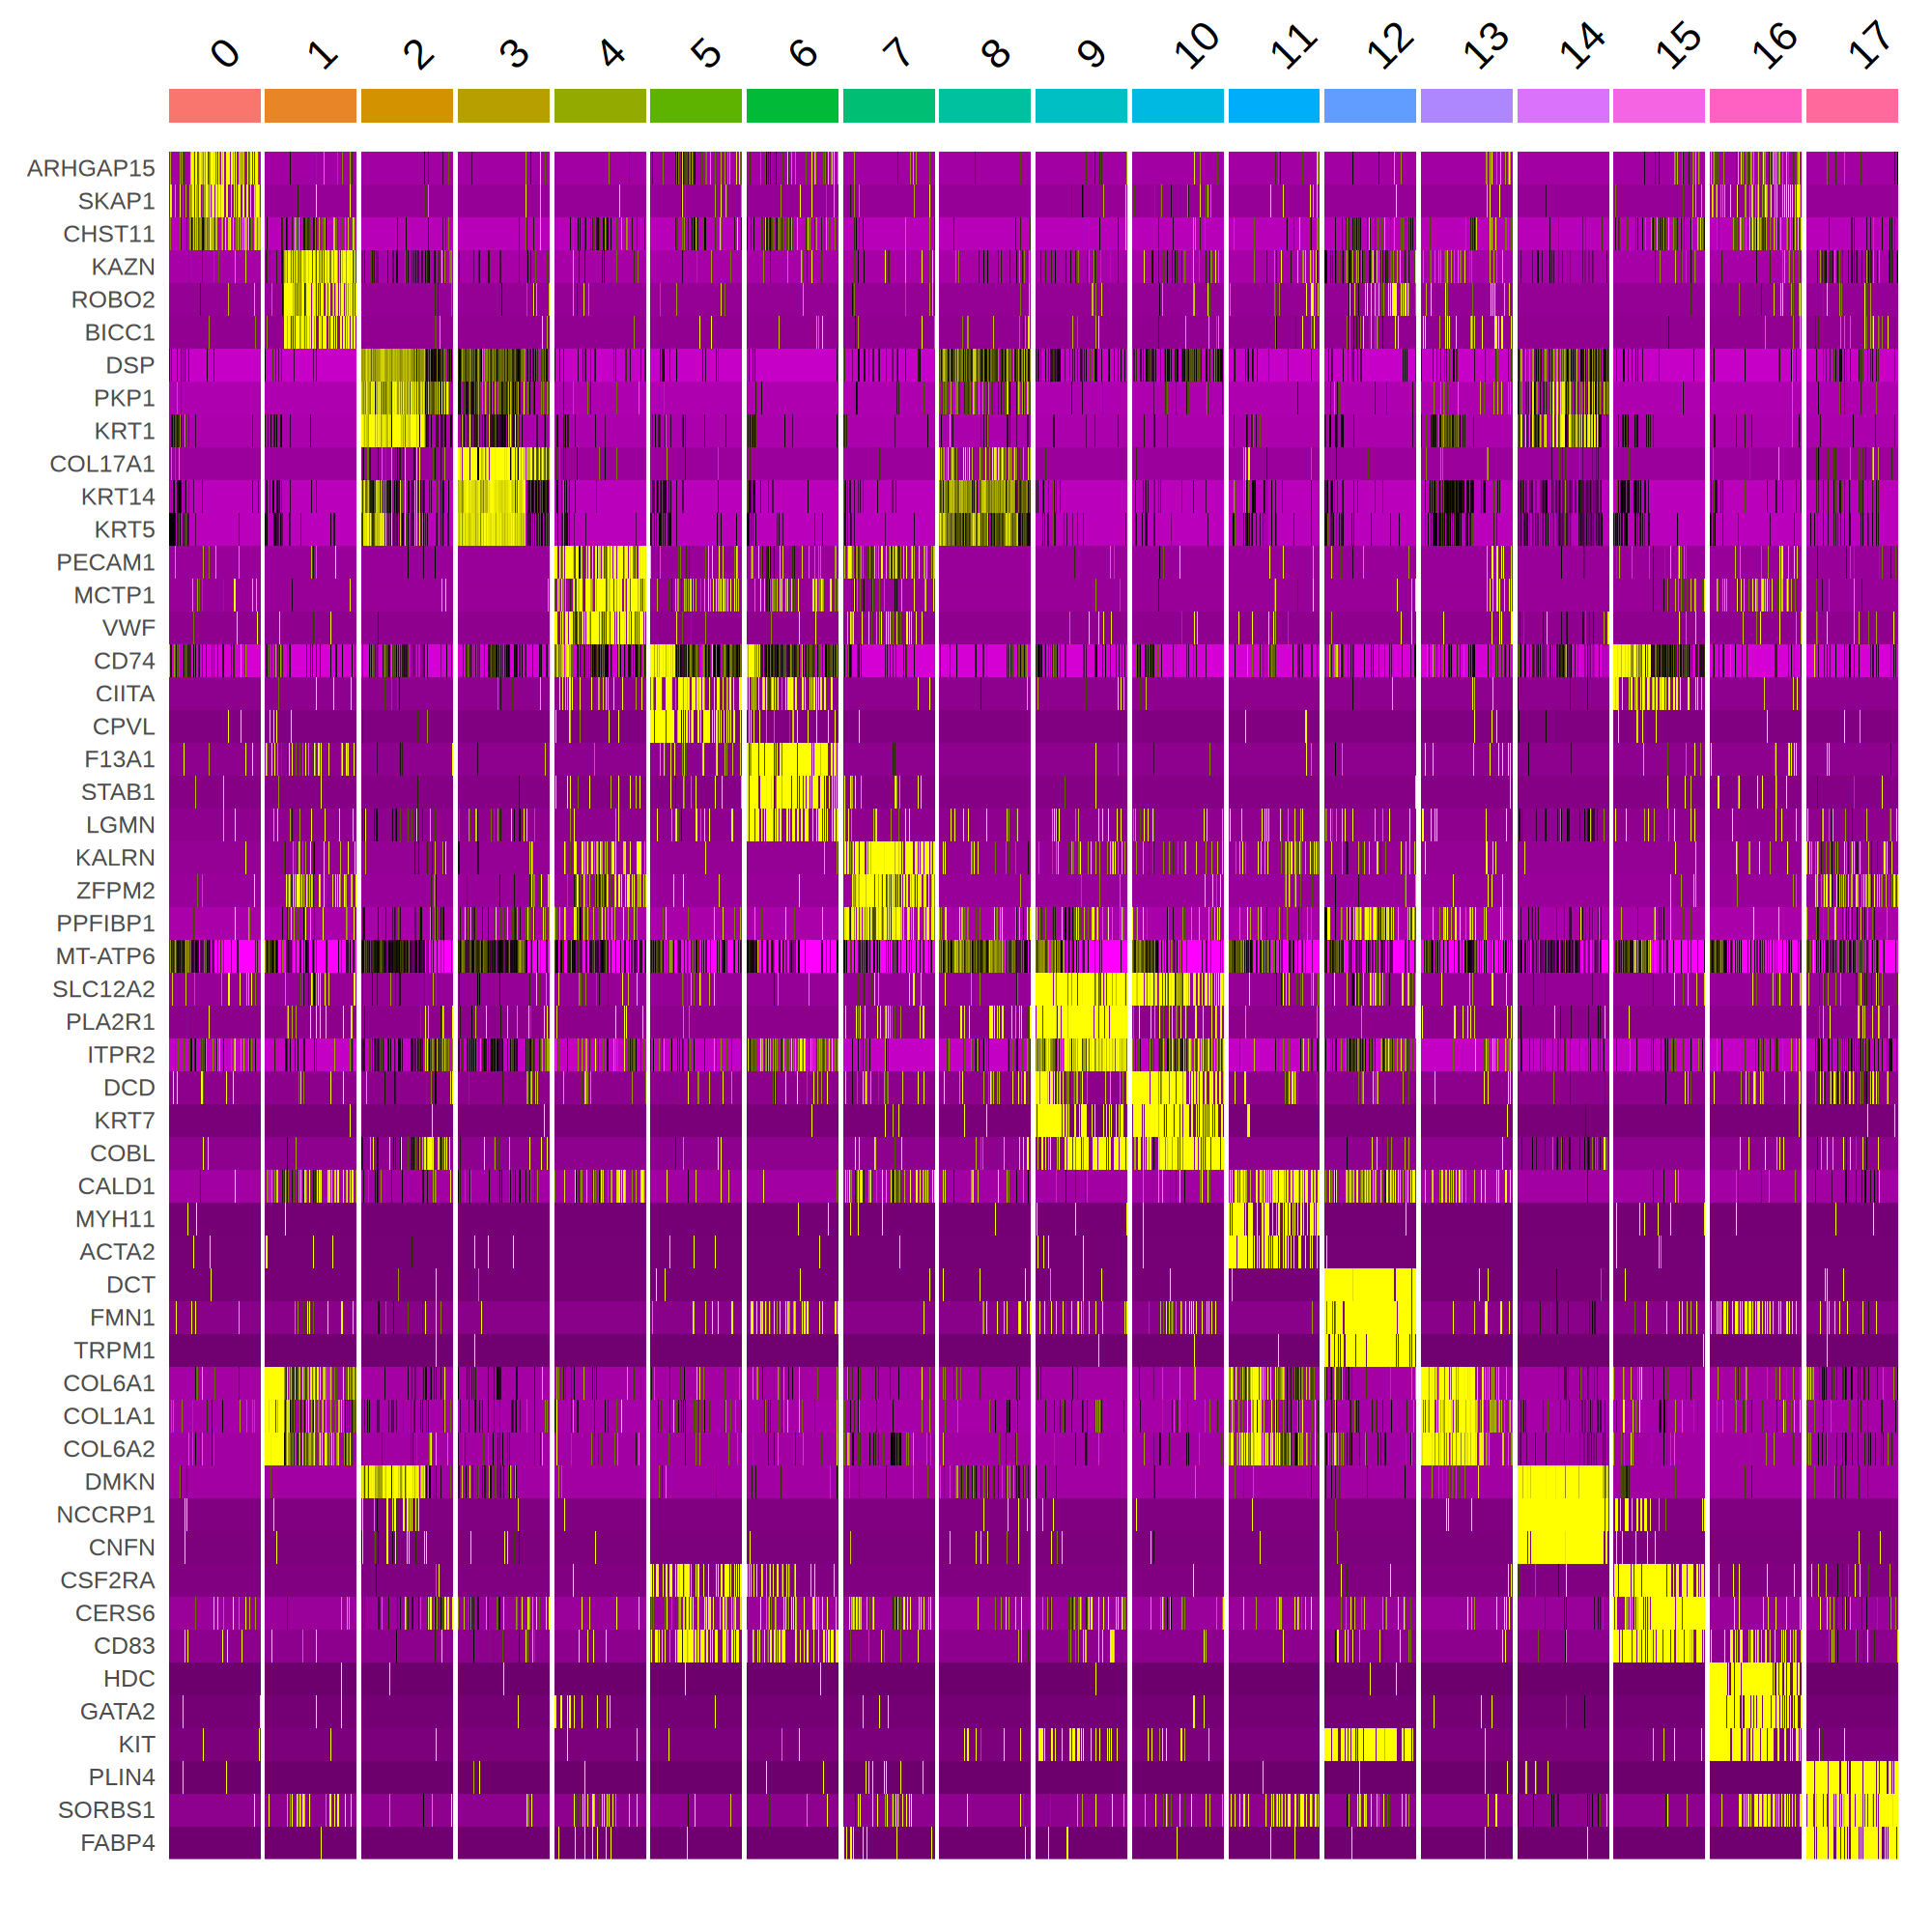

In [11]:
obj_presto = wilcoxauc(obj, 'seurat_clusters')
head(obj_presto)
markers = top_markers(obj_presto, n = 3)
markers = markers[, -1]
markers = markers[, as.character(0:(ncol(markers)-1))]
head(markers)

fig.size(10, 10)
DoHeatmap(subset(obj, downsample = 100), features = unlist(markers)) + NoLegend()

## Plot marker genes

In [12]:
obj_tmp = obj
obj_tmp@meta.data = obj_tmp@meta.data[, 1:14]

obj_tmp = obj_tmp %>% 
              AddModuleScore(features = list(c("KRT5", "KRT14")), name = "Keratinocyte undiff.") %>%
              AddModuleScore(features = list(c("KRT1", "KRT10")), name = "Keratinocyte diff.") %>%
              AddModuleScore(features = list(c("MLANA", "BCAN", "DCT")), name = "Melanocyte") %>%
              AddModuleScore(features = list(c("KRT15", "KRT19")), name = "Hair follicle") %>%
              AddModuleScore(features = list(c("PLIN1", "FABP4", "LPL")), name = "Dermal adipocyte") %>%
              AddModuleScore(features = list(c("PDGFRA", "LUM", "COL6A1", "COL1A2")), name = "Fibroblast") %>%
              AddModuleScore(features = list(c("ACTA2", "MYH11")), name = "Pericyte") %>%
              AddModuleScore(features = list(c("CDH5", "SELE", "SOX17", "VWF")), name = "Vascular EC") %>%
              AddModuleScore(features = list(c("PROX1", "LYVE1")), name = "Lymphatic EC") %>%
              AddModuleScore(features = list(c('KIT', 'MS4A2', "HDC")), name = 'Mast') %>%
              AddModuleScore(features = list(c("LYZ", "AIF1", "CD68", "CD83")), name = "Macrophage/DC") %>%
              AddModuleScore(features = list(c("LCK", "CD3E", "CD3D", "CD3G")), name = "T cell")
              
              #AddModuleScore(features = list(c("CD79A", "MEF2C", "PKHD1L1")), name = "B_cell") %>%
              #AddModuleScore(features = list(c("FAM210B", "GYPC", "HBA1", "HBB")), name = "Erythrocyte") %>%
              #AddModuleScore(features = list(c("CAPNS2", "PTN", "SOSTDC1", "TMEM45A")), name = "Pilosebaceous") %>%        
              #AddModuleScore(features = list(c("AQP3", "AREG", "CDK1", "FGFBP1", "ITGA6")), name = "EpSC+Other_prog") %>%
              #AddModuleScore(features = list(c("SFRP1", "TFAP2A", "THBS2", "COL17A1", "CXADR")), name = "TSK_basal") %>%
              #AddModuleScore(features = list(c("CBFA2T3", "PKIB", "SLC8A1")), name = "ASDC") %>%
              #AddModuleScore(features = list(c('FLG', 'LOR')), name = 'Granular') %>%)
              #AddModuleScore(features = list(c("CTSW", "NCAM1")), name = "NK")

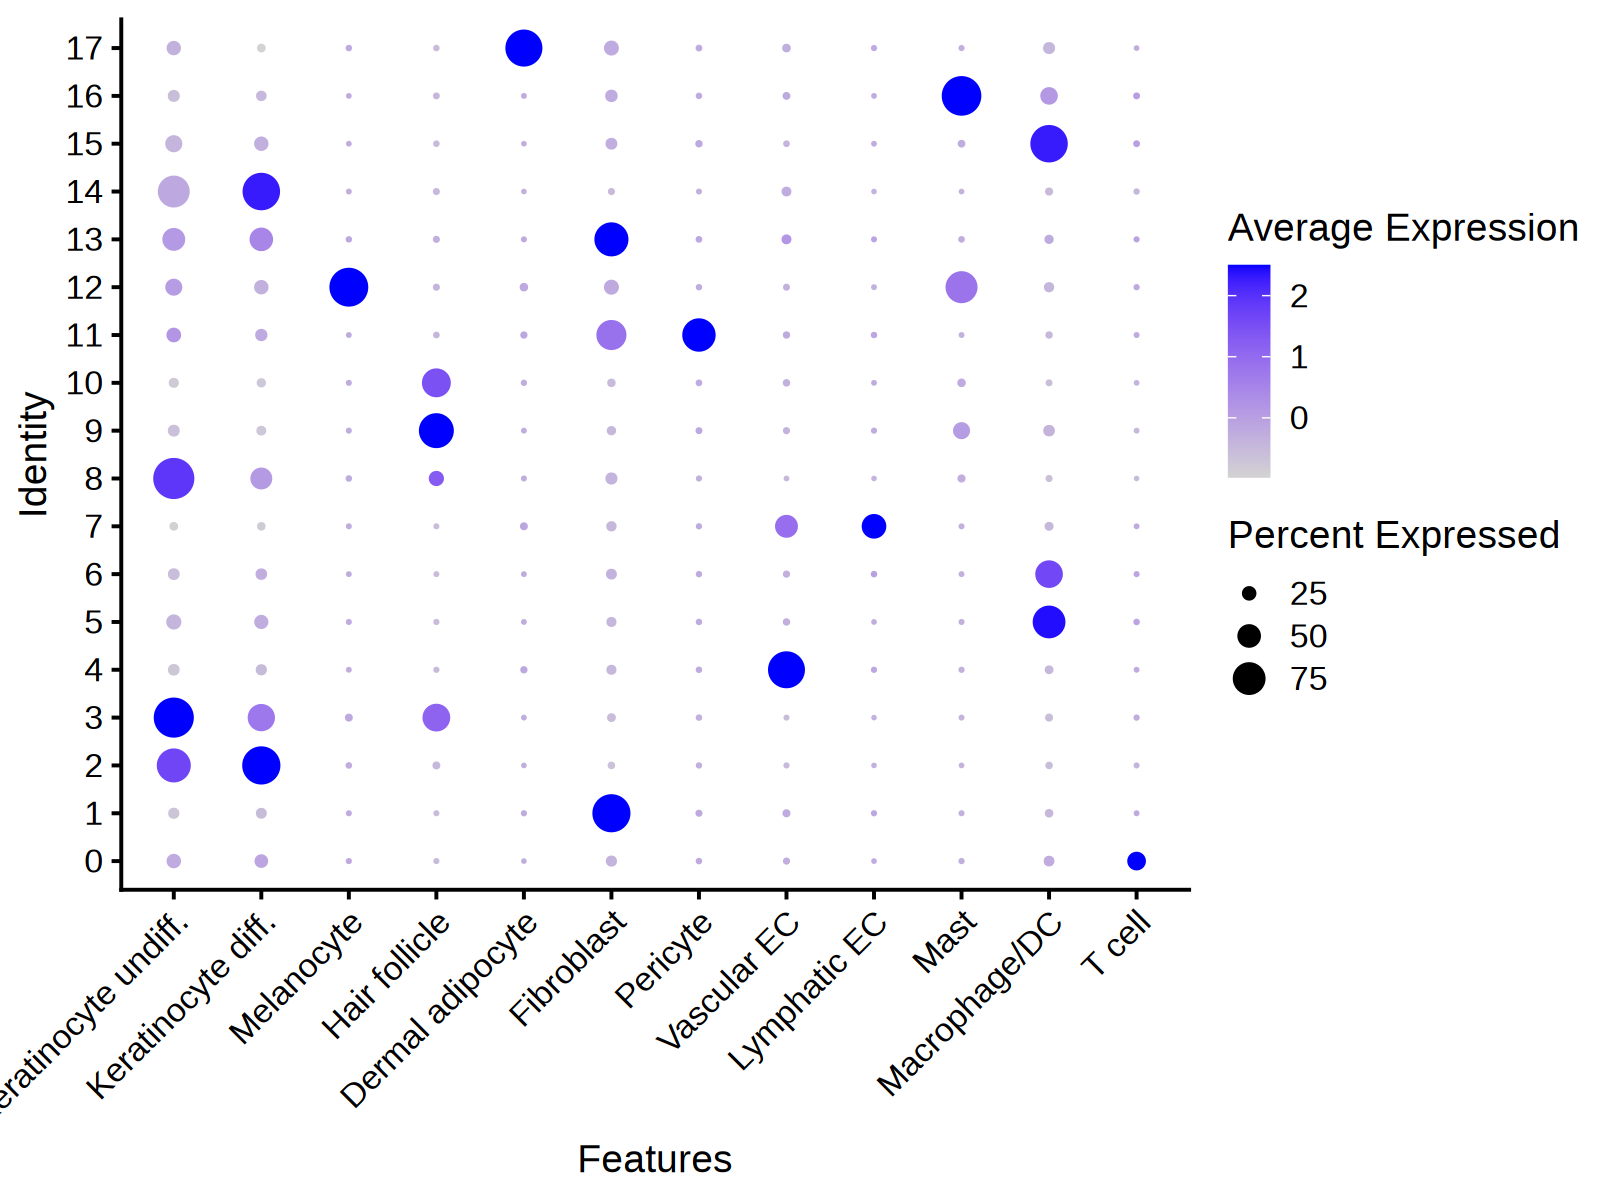

In [13]:
colnames(obj_tmp@meta.data) = sub("1$", "", names(obj_tmp@meta.data))
features = c("Keratinocyte undiff.", "Keratinocyte diff.", "Melanocyte", "Hair follicle", "Dermal adipocyte",
             "Fibroblast", "Pericyte", "Vascular EC", "Lymphatic EC", 'Mast', "Macrophage/DC", "T cell")
fig.size(6, 8)
DotPlot(obj_tmp, features = features) + RotatedAxis()

## Assign cell labels

In [14]:
# Add cluster identities
new.cluster.ids = c("T cell",
                    "Fibroblast", 
                    "Keratinocyte diff.",
                    "Keratinocyte undiff.",
                    "Vascular EC",
                    "Myeloid",
                    "Myeloid",
                    "Lymphatic EC",
                    "Keratinocyte undiff.",
                    "Hair follicle", 
                    "Hair follicle",
                    "Pericyte",
                    "Melanocyte",
                    "Fibroblast",
                    "Keratinocyte diff.",
                    "Myeloid",
                    "Mast",
                    "Dermal adipocyte")
names(new.cluster.ids) = levels(obj)
obj = RenameIdents(obj, new.cluster.ids)
obj@meta.data$cell_type = Idents(obj)

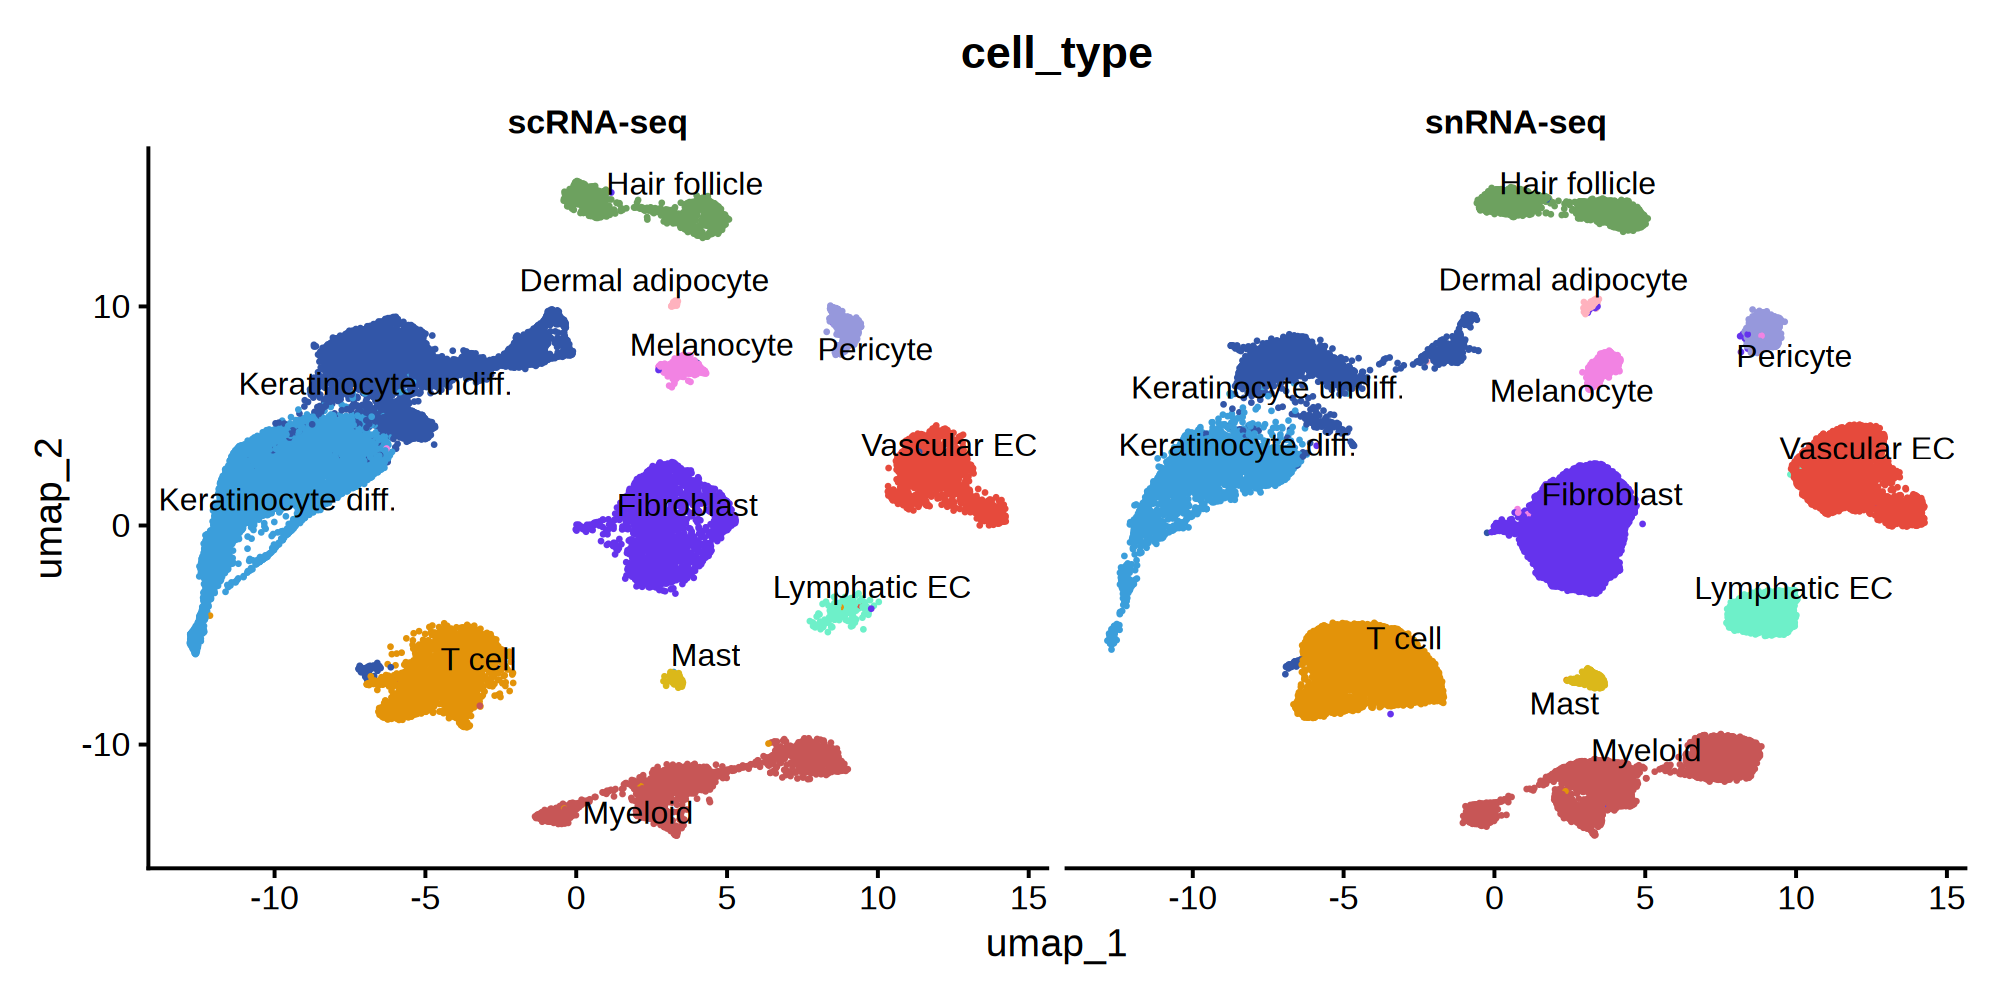

In [15]:
fig.size(5, 10)
DimPlot(obj, reduction = "umap", label = TRUE, pt.size = 0.2, 
        repel = TRUE, shuffle = TRUE, seed = 1, group.by = 'cell_type', split.by = 'dataset') + 
        NoLegend() + scale_color_manual(values = custom.colors)

In [16]:
colnames(obj@meta.data)

[1] "orig.ident"            "nCount_RNA"            "nFeature_RNA"         
 [4] "Cell"                  "Run"                   "Run_ID"               
 [7] "Subject"               "PatientID"             "TimePt"               
[10] "Identity"              "Sample_TimePt"         "dataset"              
[13] "percent.mt"            "scrublet_score"        "RNA_snn_res.0.5"      
[16] "seurat_clusters"       "cell_type"             "souporcell_status"    
[19] "souporcell_assignment" "Type"                  "Condition"            
[22] "RNA_snn_res.0.2"

In [17]:
obj@meta.data$Condition = ifelse(is.na(obj@meta.data$Condition), 
                                 paste0('LesTx_', obj@meta.data$TimePt), obj@meta.data$Condition)

In [18]:
table(obj$dataset)
table(obj$dataset, obj$Condition)


scRNA-seq snRNA-seq 
    27448     43854 

           
            LesTx_Wk0 LesTx_Wk8 LesUntx_Wk0 LesUntx_Wk24 NL_Wk0
  scRNA-seq     17499      9949           0            0      0
  snRNA-seq         0         0       15191        21616   7047

In [19]:
table(obj$cell_type, obj$Condition)

                      
                       LesTx_Wk0 LesTx_Wk8 LesUntx_Wk0 LesUntx_Wk24 NL_Wk0
  T cell                    2968       372        4684         4745    334
  Fibroblast                1645       805        2801         4802   1382
  Keratinocyte diff.        4770      2941        1069         1186    648
  Keratinocyte undiff.      4405      3574         669          789   1042
  Vascular EC                948       671        2003         3119    952
  Myeloid                   1674       414        2203         3158    336
  Lymphatic EC               123        52         613         1166    862
  Hair follicle              296       645         415         1494    696
  Pericyte                   289       293         296          477    189
  Melanocyte                 241       133         244          378    292
  Mast                       133        14         191          216     79
  Dermal adipocyte             7        35           3           86    235

In [21]:
# Save labels and umap coordinates

idx_scRNA = which(obj@meta.data$dataset == 'scRNA-seq')
ct_scRNA = obj@meta.data$cell_type[idx_scRNA]
umap_scRNA = obj@reductions$umap@cell.embeddings[idx_scRNA, c('umap_1', 'umap_2')]
colnames(umap_scRNA) = c('merged_UMAP_1', 'merged_UMAP_2')

idx_snRNA = which(obj@meta.data$dataset == 'snRNA-seq')
umap_snRNA = obj@reductions$umap@cell.embeddings[idx_snRNA, c('umap_1', 'umap_2')]
colnames(umap_snRNA) = c('merged_UMAP_1', 'merged_UMAP_2')

obj_scRNA_labels = obj@meta.data %>% filter(dataset == 'scRNA-seq') %>% dplyr::select(Cell, cell_type) %>% 
    cbind(umap_scRNA)
obj_snRNA_labels = obj@meta.data %>% filter(dataset == 'snRNA-seq') %>% dplyr::select(Cell, cell_type) %>%
    cbind(umap_snRNA)

write.csv(obj_scRNA_labels, '../_data/obj_merged_scRNA_labels.csv', quote = F)
write.csv(obj_snRNA_labels, '../_data/obj_merged_snRNA_labels.csv', quote = F)

In [4]:
# Save Seurat object
saveRDS(obj, '../_data/obj_merged_71302cells_labeled.rds')

In [5]:
max(obj@assays$RNA$data)

[1] 8.854594

# Done!

In [26]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /PHShome/jbk37/anaconda3/envs/resiq1/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] rlang_1.1.3                 org.Hs.eg.db_3.18.0        
 [3] AnnotationDbi_1.64.1        msigdbr_7.5.1              
 [5] clusterProfiler_4.10.0      patchwork_1.3.0.9000       
 [7] RColorBrewer_1.